# HRN Output Analysis

This notebook analyzes seeded training/test artifacts in `/scratch/g.saggini1/outputs/`. Each experiment is a parent directory containing `seed_<seed>` runs; curves and final metrics report the mean and sample standard deviation across those seeds.

It compares:

- HRN baselines
- HRN runs wrapped with the shared orthonormal taxonomy-frame plugin, without lexicographic projection

It uses the same analysis utilities and plotting layout as `hcast_analysis.ipynb`, with run names changed to HRN.

In [81]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / 'configs').exists() else cwd.parent
notebook_utils_dir = repo_root / 'notebooks'
if str(notebook_utils_dir) not in sys.path:
    sys.path.insert(0, str(notebook_utils_dir))

from hcast_analysis_utils import (
    HCastAnalysis as HRNAnalysis,
    HCastAnalysisConfig as HRNAnalysisConfig,
    resolve_project_root,
)

PROJECT_ROOT = resolve_project_root()
OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
print(f'Using project root: {PROJECT_ROOT}')


Using project root: /home/g.saggini1/lexicographic_deep_learning_detailed_study


In [82]:
INCLUDE_BASELINES = True
INCLUDE_TOPDOWN_METRICS = True
BASELINE_COLOR = '#243ab4'

DATASET_SLUGS = {
    'cifar-100': 'cifar100',
    'cub-200-2011': 'cub200',
    'fgvc-aircraft': 'aircraft',
}
HRN_DATASETS = tuple(DATASET_SLUGS.values())

BASELINE_BY_DATASET = {
    dataset_key: {'run_dir': f'hrn_{dataset}', 'label': 'HRN baseline'}
    for dataset_key, dataset in DATASET_SLUGS.items()
}

PLUGIN_LOSS_MODE = 'level_softmax_ce_reg'
PLUGIN_LOSS_LABEL = 'level softmax CE+reg'
PLUGIN_WEIGHT_MODE = 'kl_leaf'

MANUAL_RUNS = [
    # HRN with the shared orthonormal plugin, non-lex mode.
    *[
        {'run_dir': f'hrn_{dataset}_orthonormal_plugin_{PLUGIN_LOSS_MODE}_final_only_identity',
         'label': f'HRN plugin {PLUGIN_LOSS_LABEL} final_only_identity'}
        for dataset in HRN_DATASETS
    ],
]

TEMPERATURE_COLOR_PALETTE = [
    '#d62728',
    '#2ca02c',
    '#ff7f0e',
    '#9467bd',
    '#8c564b',
    '#17becf',
    '#e377c2',
    '#bcbd22',
]

In [83]:
config = HRNAnalysisConfig(
    outputs_root=OUTPUTS_ROOT,
    include_baselines=INCLUDE_BASELINES,
    include_topdown_metrics=INCLUDE_TOPDOWN_METRICS,
    baseline_color=BASELINE_COLOR,
    baseline_by_dataset=BASELINE_BY_DATASET,
    manual_runs=MANUAL_RUNS,
    temperature_color_palette=TEMPERATURE_COLOR_PALETTE,
)

analysis = HRNAnalysis.from_config(config)
analysis.print_run_summary()

Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_cifar100_orthonormal_plugin_level_softmax_ce_reg_final_only_identity
Skipping missing/manual-invalid run: /scratch/g.saggini1/outputs/hrn_aircraft_orthonormal_plugin_level_softmax_ce_reg_final_only_identity
[cub-200-2011] HRN baseline: epochs=100, best_td_epoch=84, best_ind_epoch=92, baseline
[cub-200-2011] HRN plugin level softmax CE+reg final_only_identity: epochs=73, best_td_epoch=61, best_ind_epoch=49, plugin_loss=level_softmax_ce_reg, plugin_weight=kl_leaf, plugin_transform=final_only, plugin_alpha=0.15


## HRN Variants: Validation Curves (Per Dataset)

Each panel overlays both decoding modes on the **same axes**:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

This makes decoder dependence visible while comparing HRN baseline against non-lex orthonormal-plugin runs.

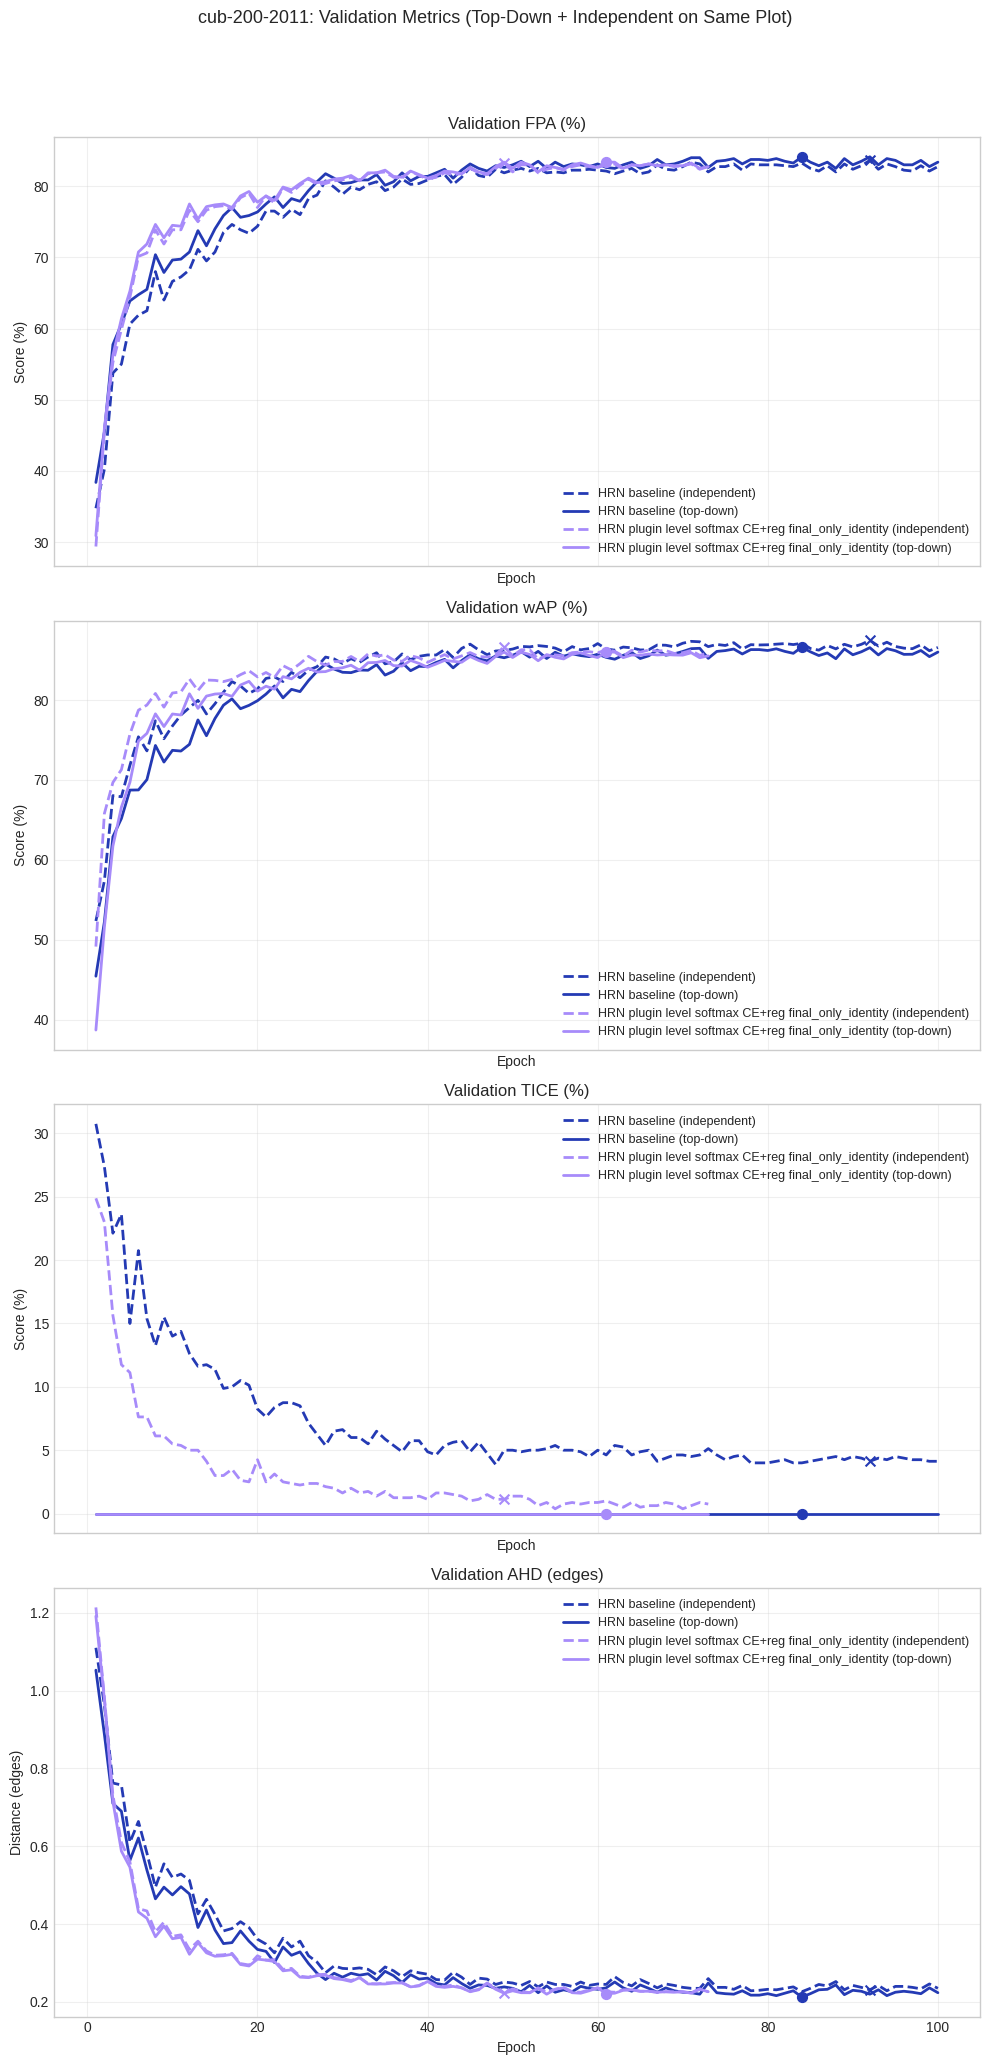

In [84]:
analysis.plot_validation_curves()


Interpretation note:
- For `FPA` and `wAP`, higher is better; for `TICE`, lower is better.
- Compare solid vs dashed lines of the same color to isolate the effect of top-down decoding.
- Compare colors within a dataset to isolate baseline HRN versus the orthonormal plugin.

## HRN Consistency Diagnostics

This section uses HRN's logged level-2 projection/parent-consistency diagnostics when present:

- projection flip rate
- projection L1 delta
- ground-truth parent mass before and after projection

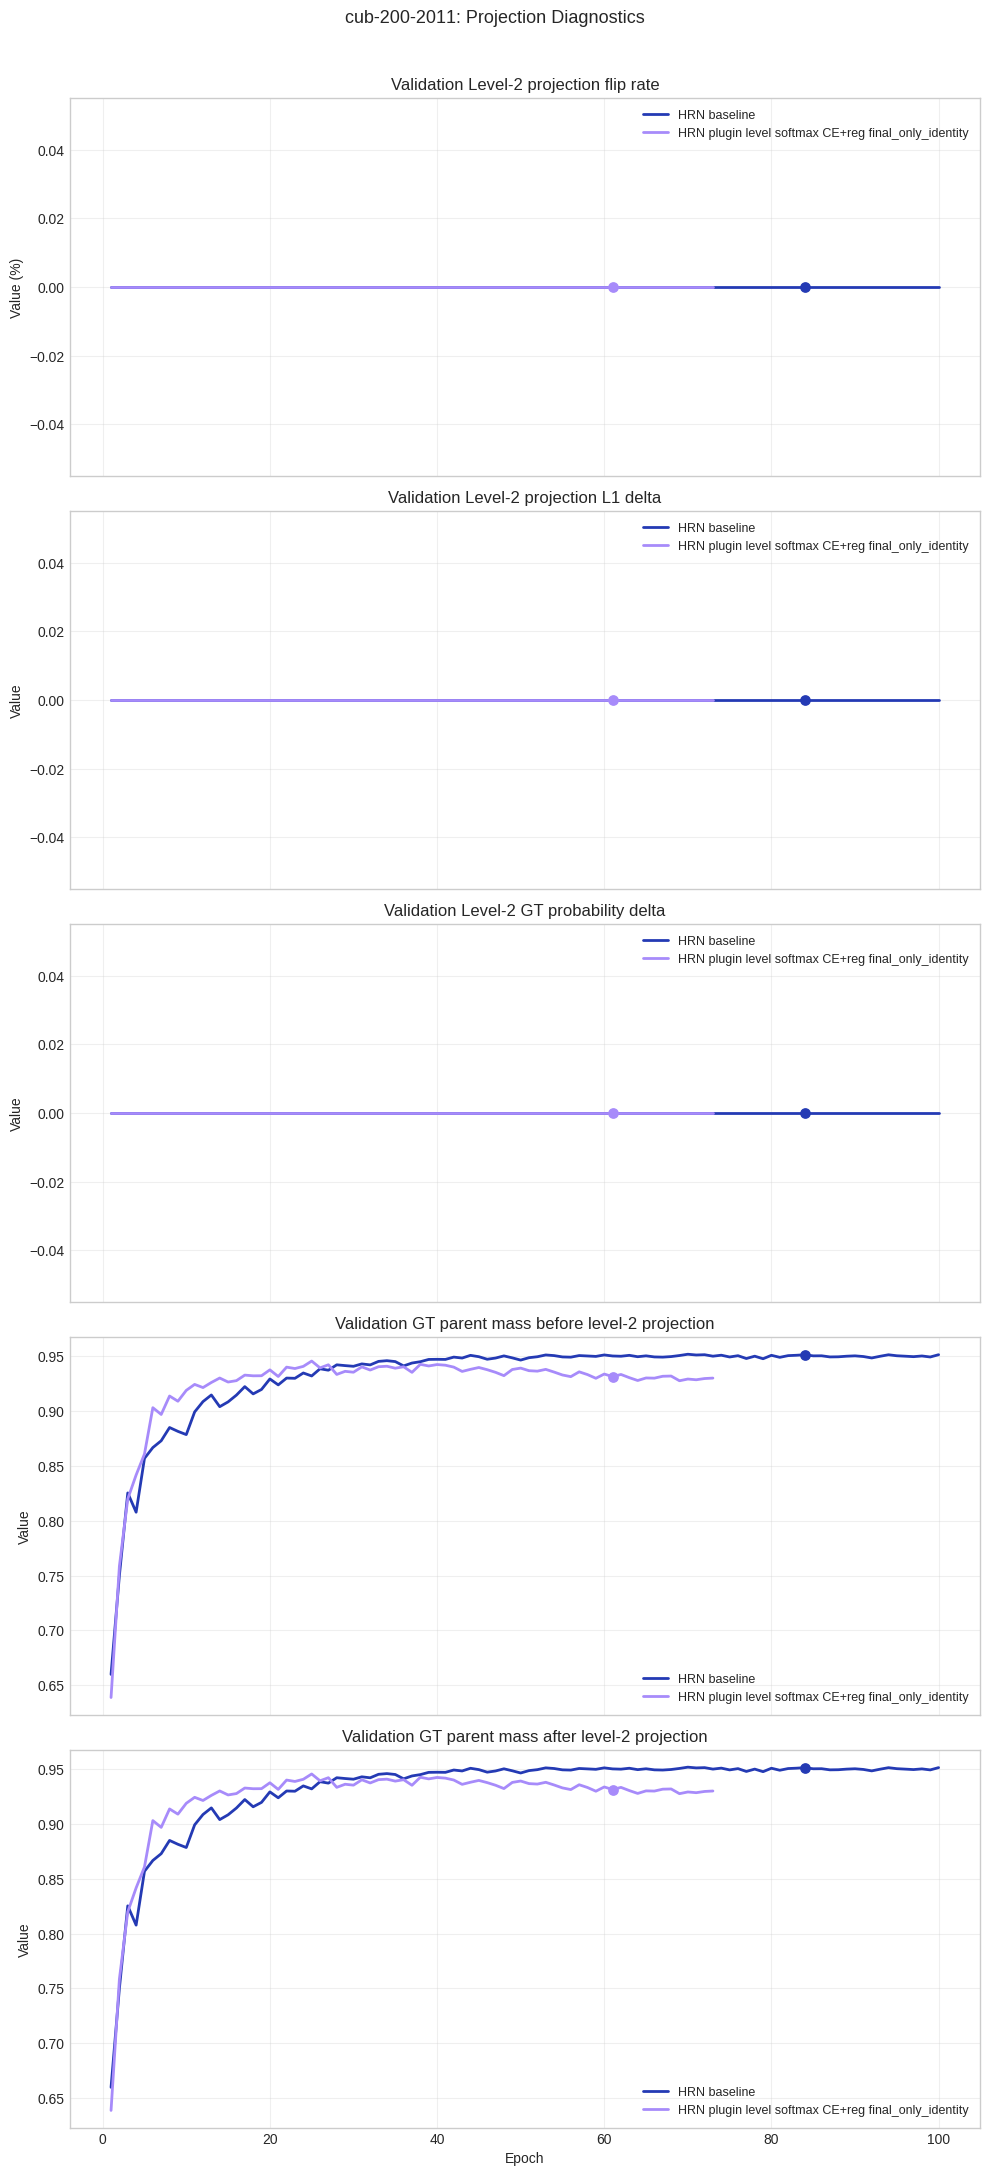

In [85]:
analysis.plot_projection_diagnostics(
    base_diag_specs=[
        ('proj_flip_rate_level_2', 'Level-2 projection flip rate', True, 'val'),
        ('proj_delta_l1_level_2', 'Level-2 projection L1 delta', False, 'val'),
        ('proj_gt_prob_delta_level_2', 'Level-2 GT probability delta', False, 'val'),
        ('gt_parent_mass_pre_l2', 'GT parent mass before level-2 projection', False, 'val'),
        ('gt_parent_mass_post_l2', 'GT parent mass after level-2 projection', False, 'val'),
    ]
)


## Training Loss Comparison

The baseline HRN losses are `tree_loss`, `hier_loss`, `ce_loss_leaf`, and `fine_ce`; plugin runs can additionally expose `ce`, `reg`, `kl`, and `loss_level_*` terms.


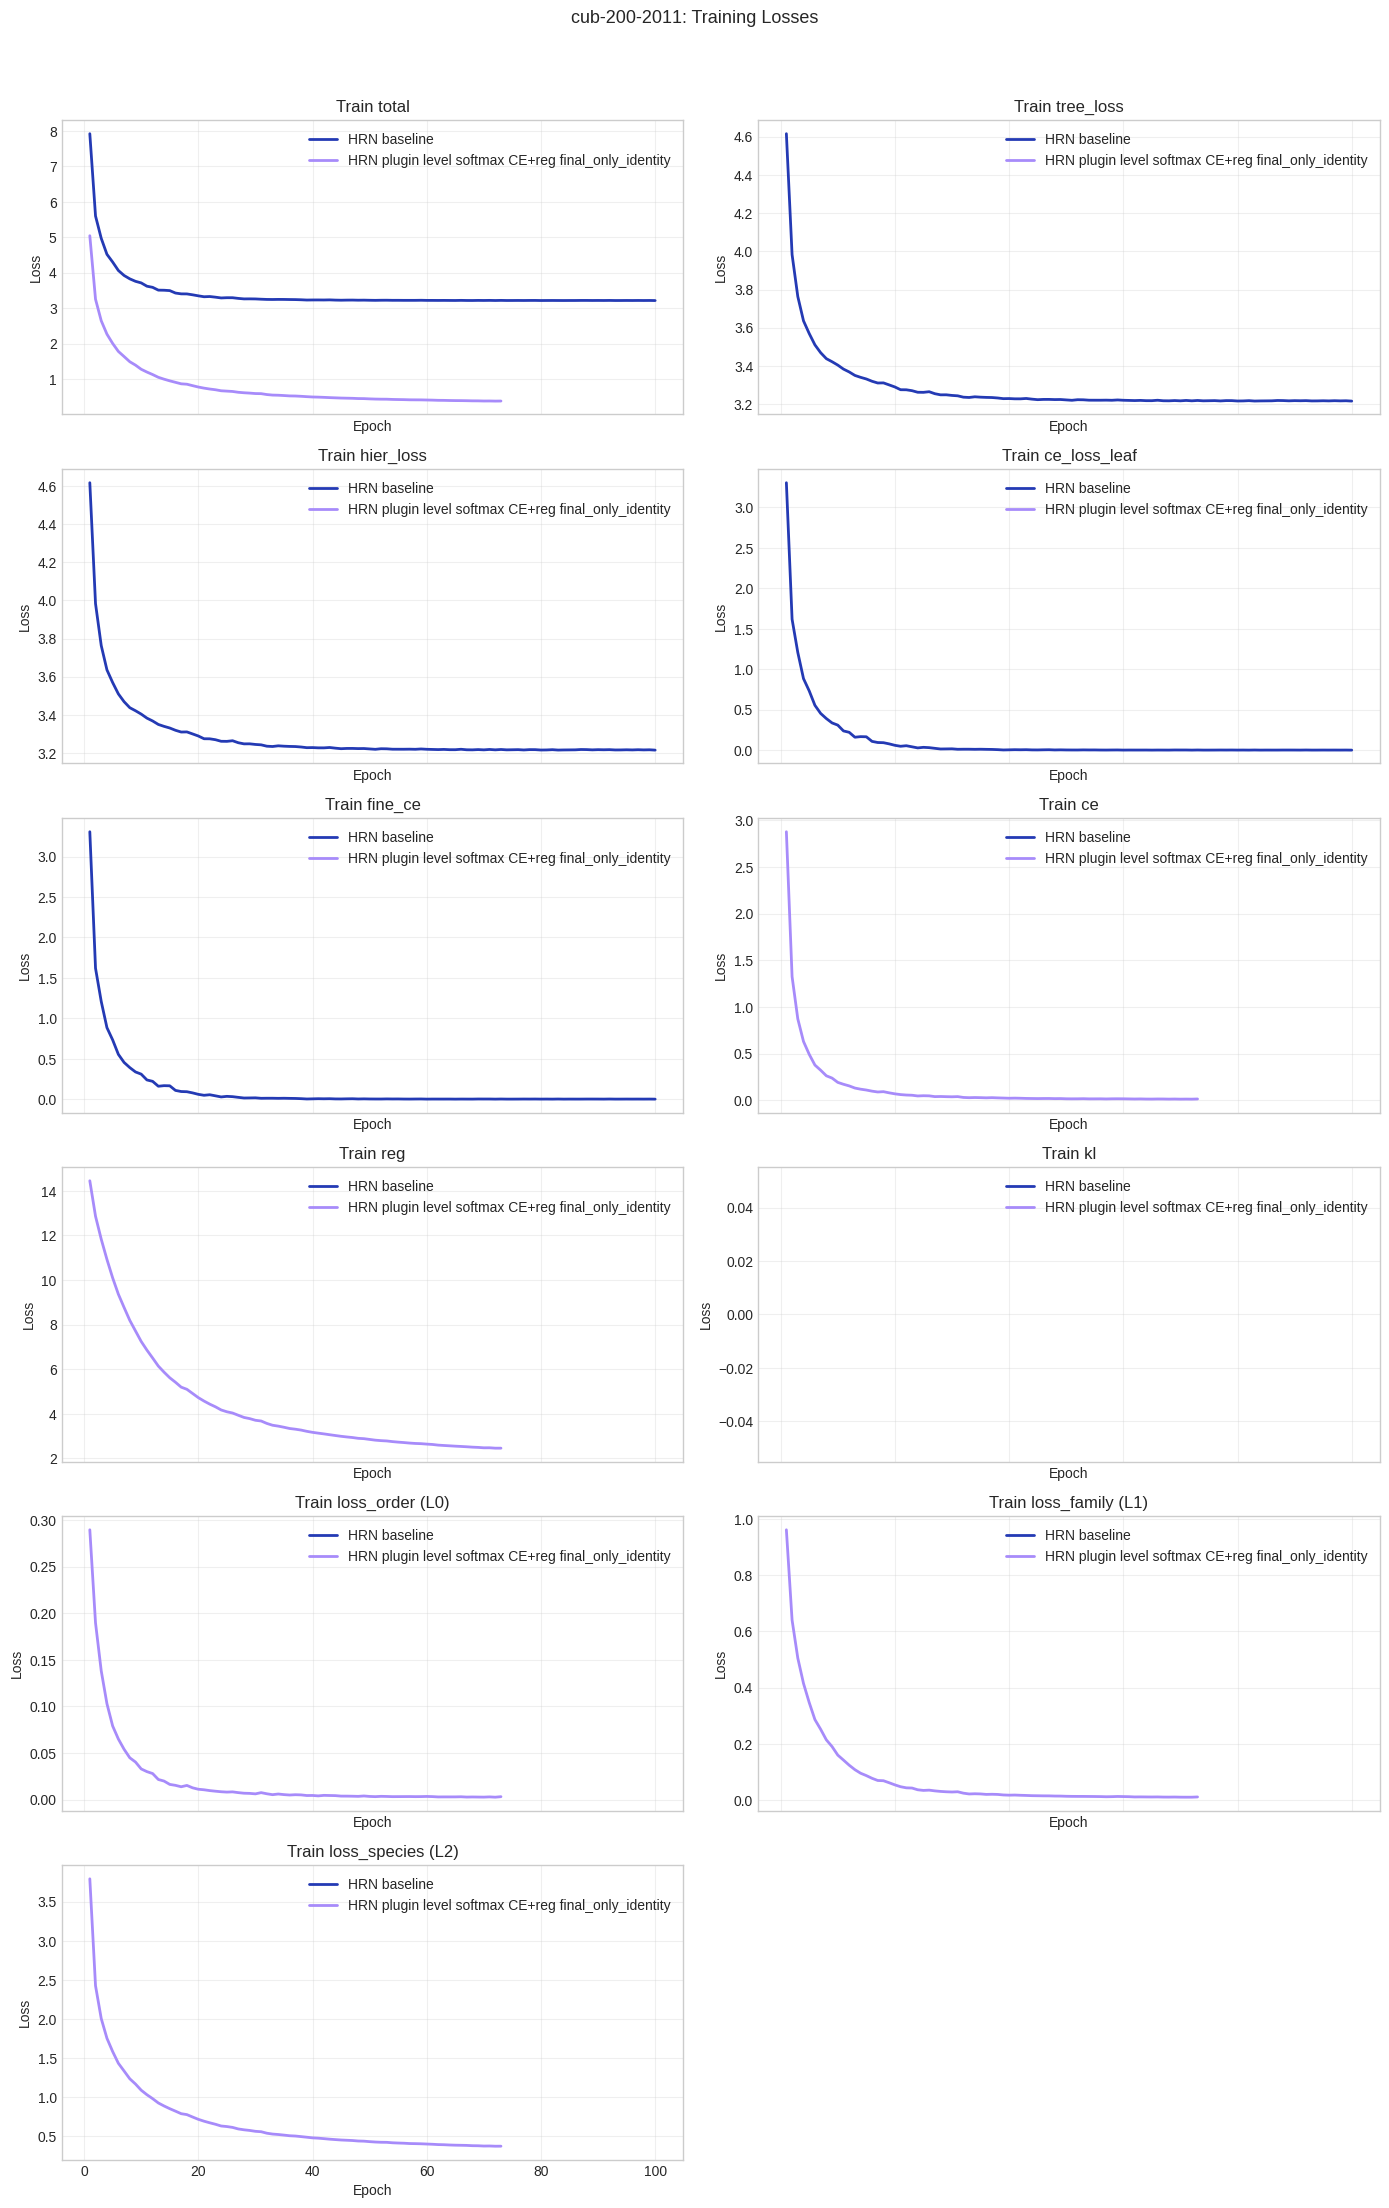

In [86]:
analysis.plot_training_losses(
    aggregate_loss_keys=['total', 'tree_loss', 'hier_loss', 'ce_loss_leaf', 'fine_ce', 'ce', 'reg', 'kl']
)


## Per-Run Per-Level Training Losses

This is mainly useful for plugin runs because the orthonormal plugin exposes per-level differentiable loss terms.


[cub-200-2011] No per-level train losses for HRN baseline


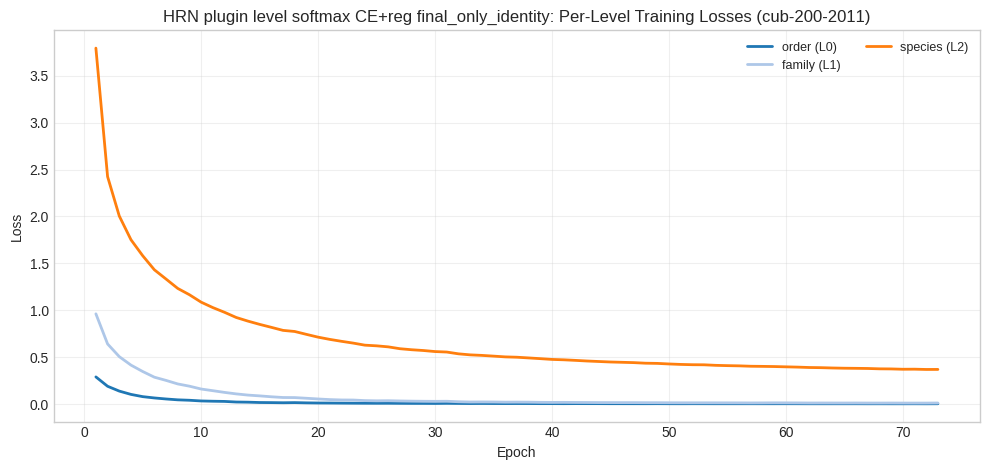

In [87]:
analysis.plot_per_run_per_level_training_losses()


## Gradient Diagnostics (Train)

This section visualizes trunk-based gradient/parameter metrics and lexicographic projection diagnostics stored in `train_metrics` for each epoch.

For the HRN non-lex runs used here, the main expected quantities are raw gradient norms/cosines and parameter movement diagnostics. No `post_*` lexicographic projection diagnostics are expected unless lexicographic training was enabled in a run.

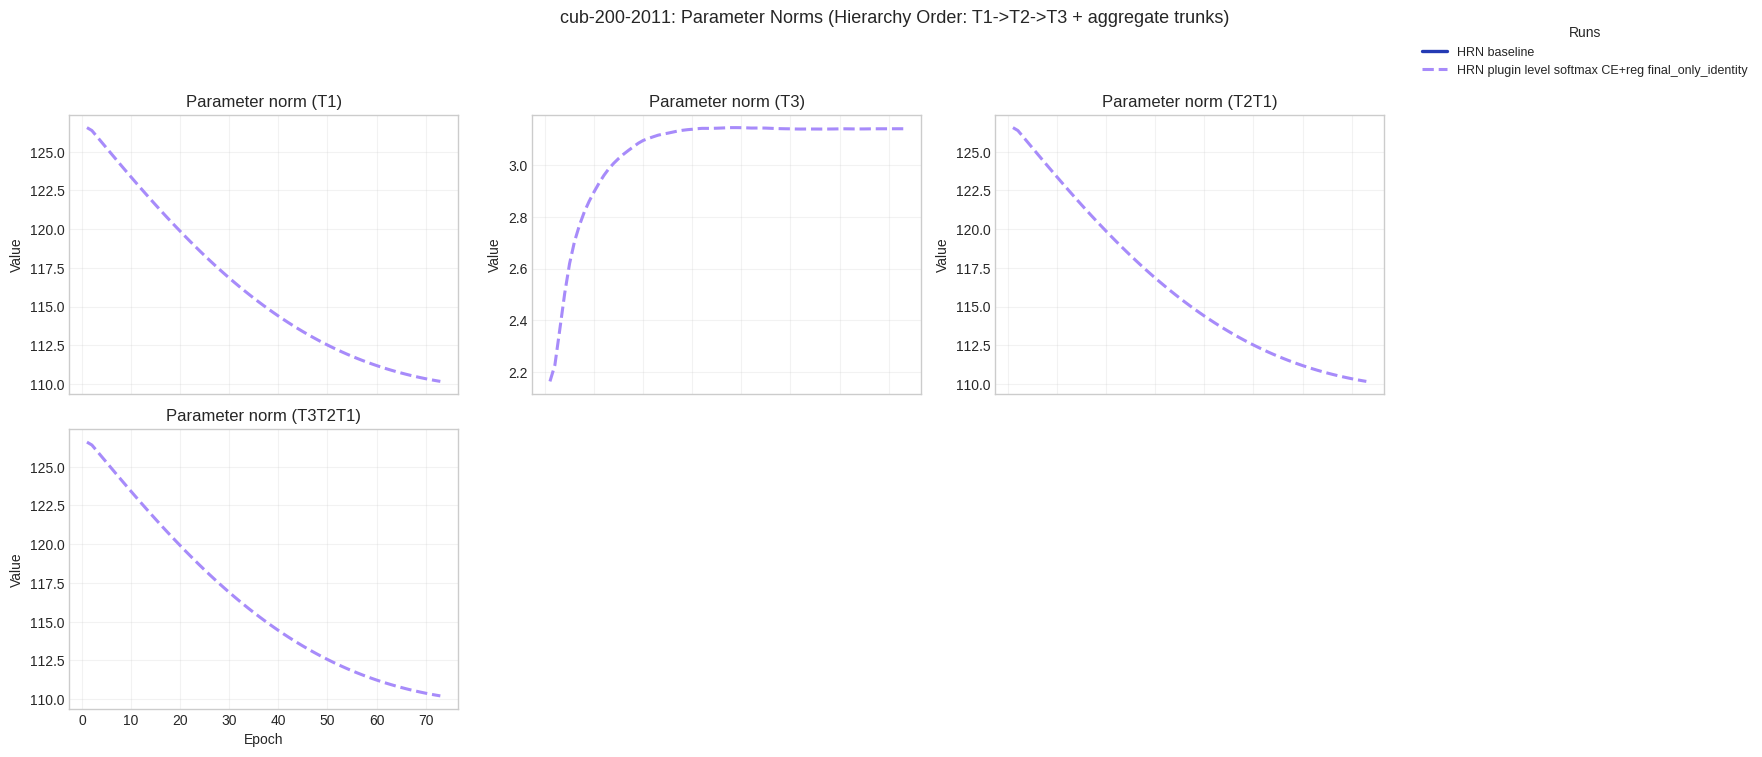

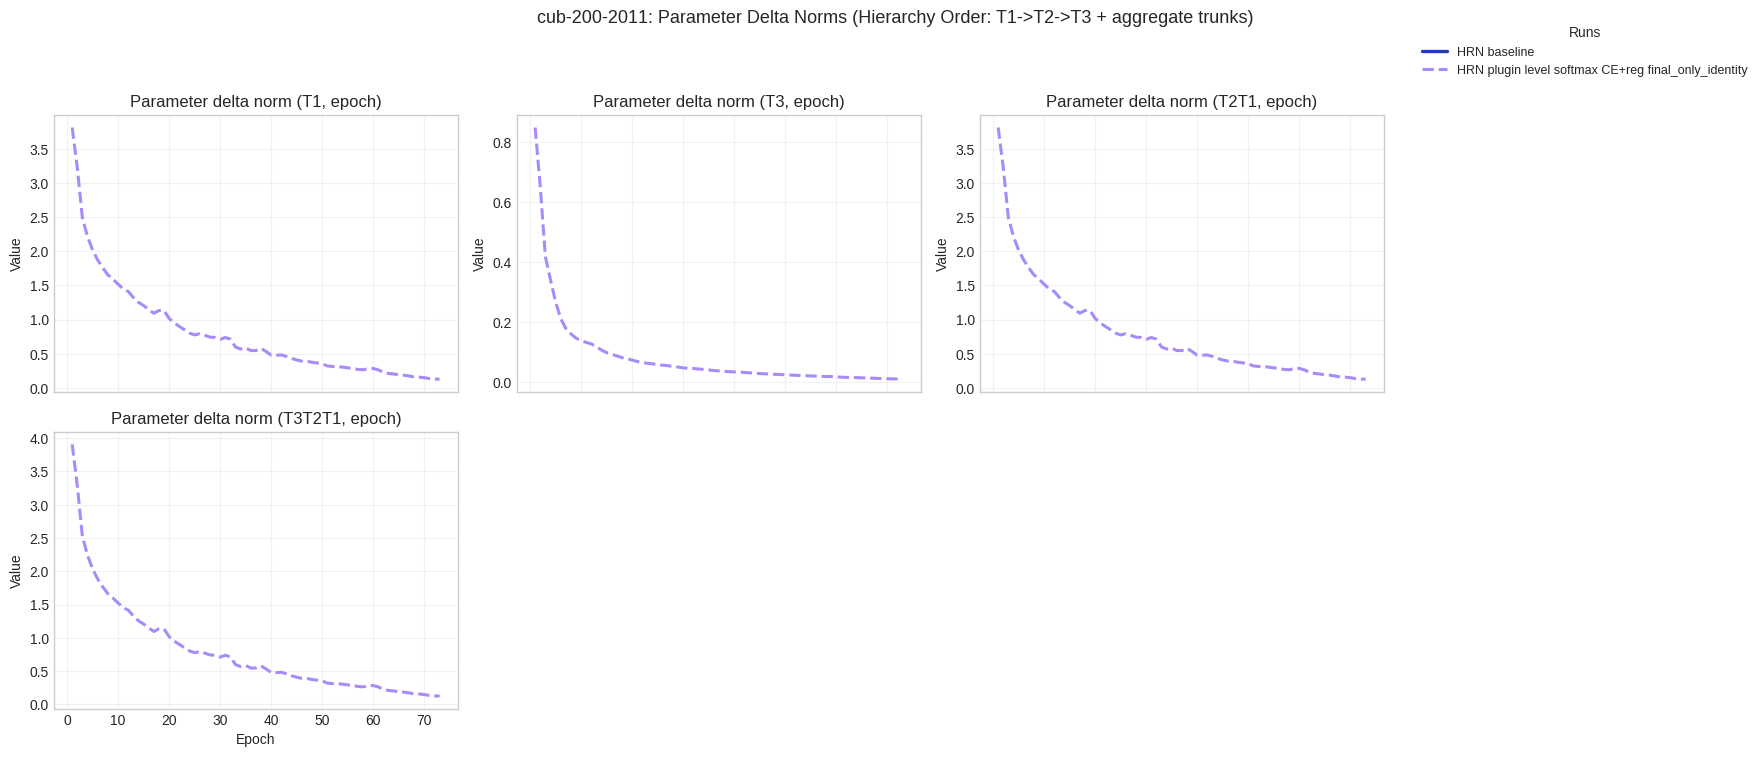

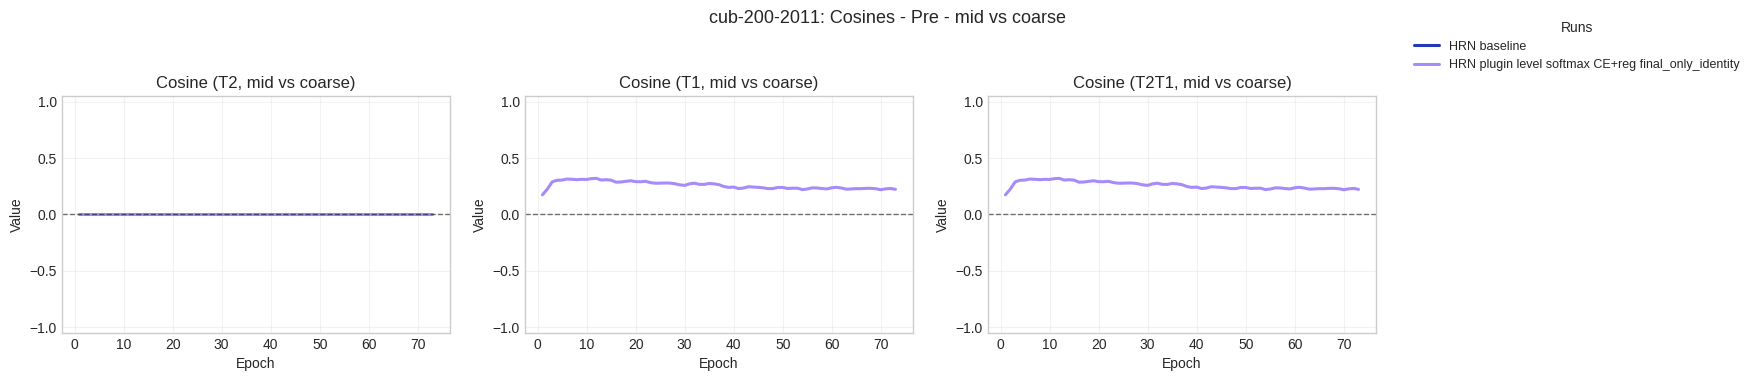

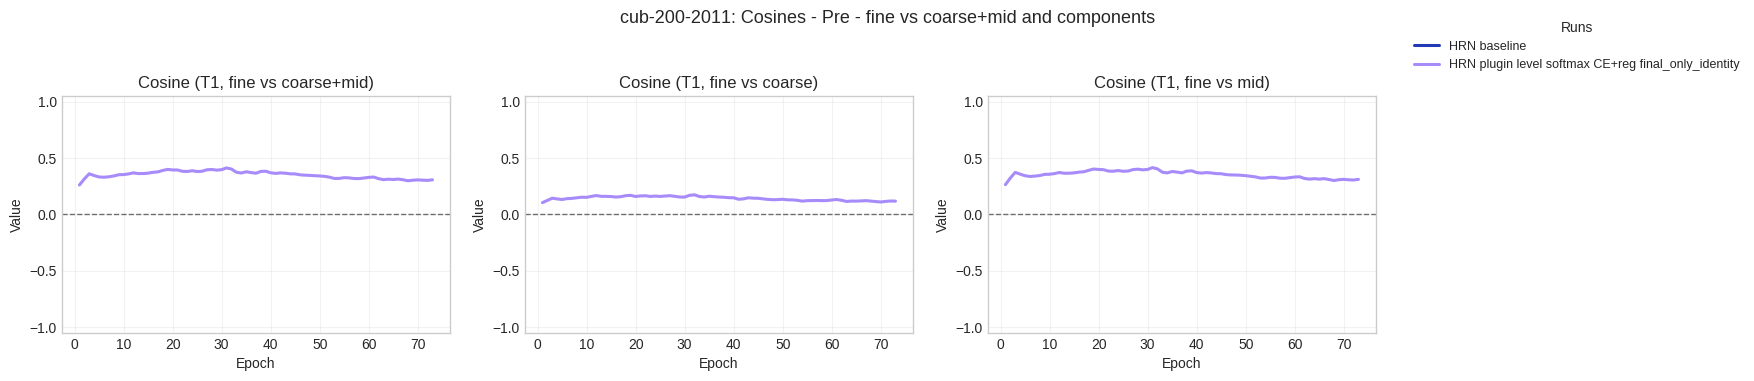

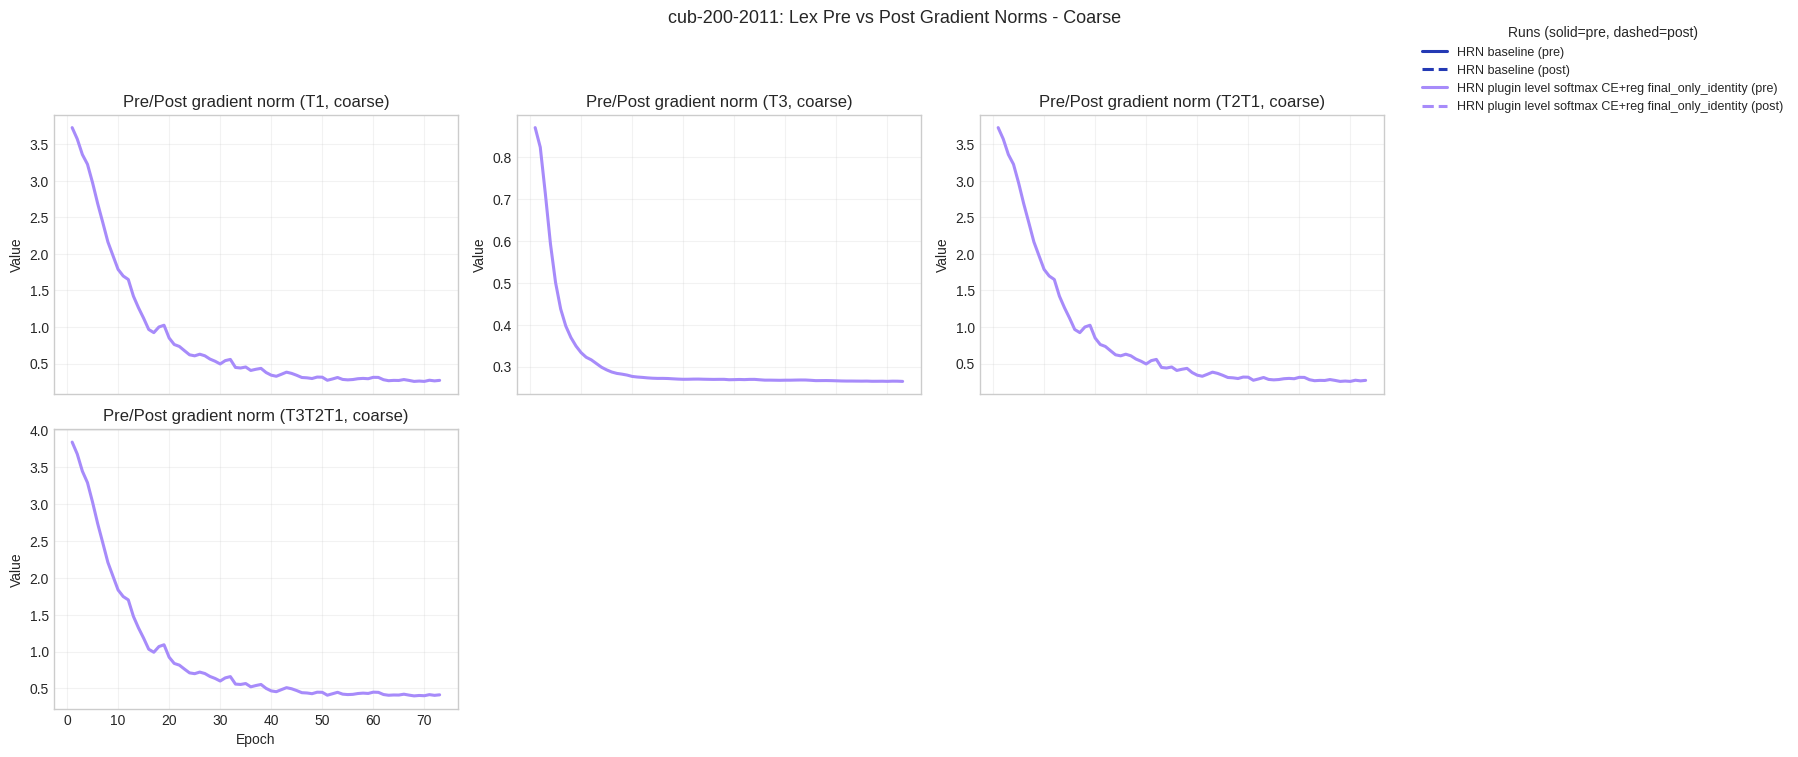

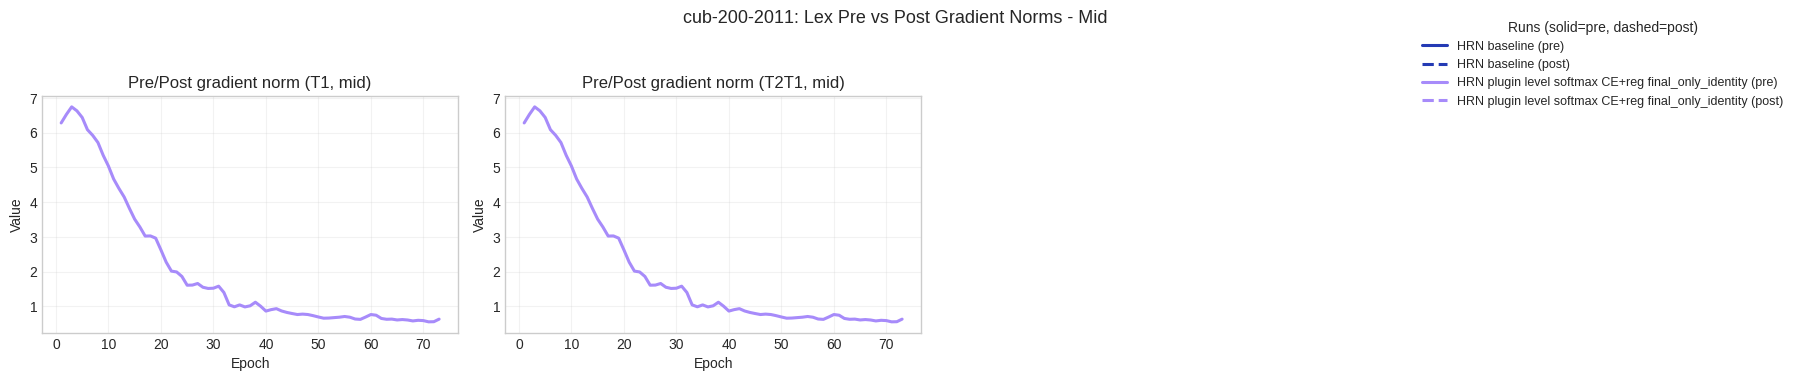

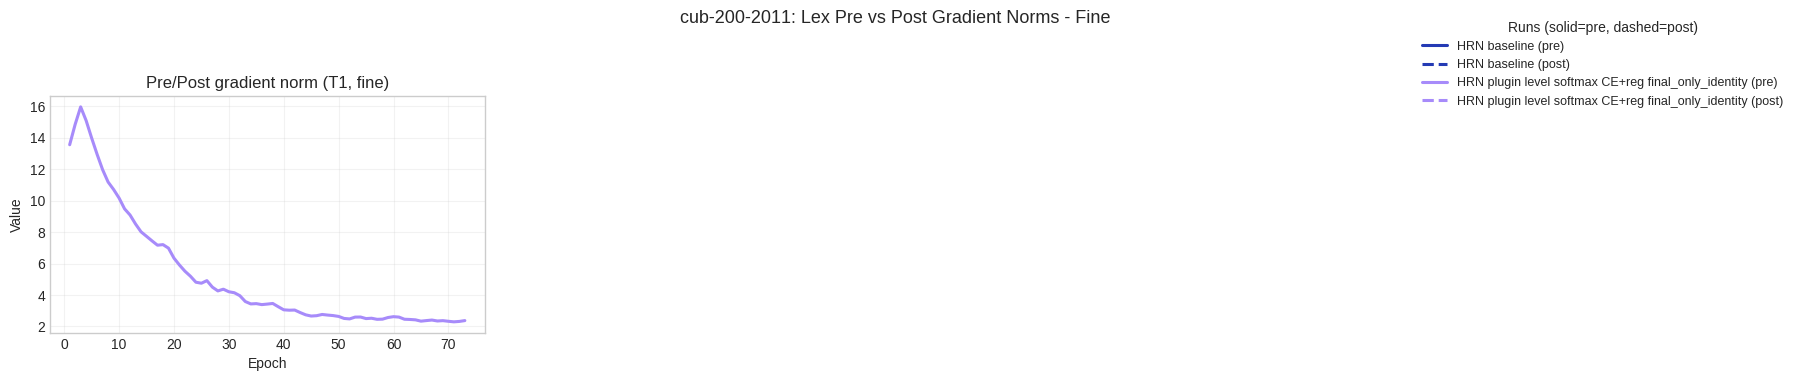

In [88]:
GRAD_SMOOTH_WINDOW = 2
SHOW_RAW_OVERLAY = False
RAW_ALPHA = 0.12
N_COLS = 3
LOG_SCALE_FOR_NORMS = False
AX_WIDTH = 6.0
AX_HEIGHT = 3.8
LEGEND_GUTTER_RATIO = 0.78
LEGEND_MAX_ROWS_PER_COL = 10

analysis.plot_gradient_diagnostics(
    smooth_window=GRAD_SMOOTH_WINDOW,
    show_raw_overlay=SHOW_RAW_OVERLAY,
    raw_alpha=RAW_ALPHA,
    n_cols=N_COLS,
    log_scale_for_norms=LOG_SCALE_FOR_NORMS,
    ax_width=AX_WIDTH,
    ax_height=AX_HEIGHT,
    legend_gutter_ratio=LEGEND_GUTTER_RATIO,
    legend_max_rows_per_col=LEGEND_MAX_ROWS_PER_COL,
)

Interpretation note:

- Large spikes in gradient norms indicate unstable update pressure for that subset/level path.
- Cosines near +1 indicate aligned objectives; cosines near -1 indicate conflict; cosines near 0 indicate near-orthogonal level gradients.
- For non-lex runs, compare raw diagnostics only; post-projection metrics are not part of the training update.

## Per-Level Validation Accuracy (Top-Down and Independent)

Each level plot overlays both modes on the same axes:

- solid line = top-down decoding
- dashed line = independent decoding
- color = run

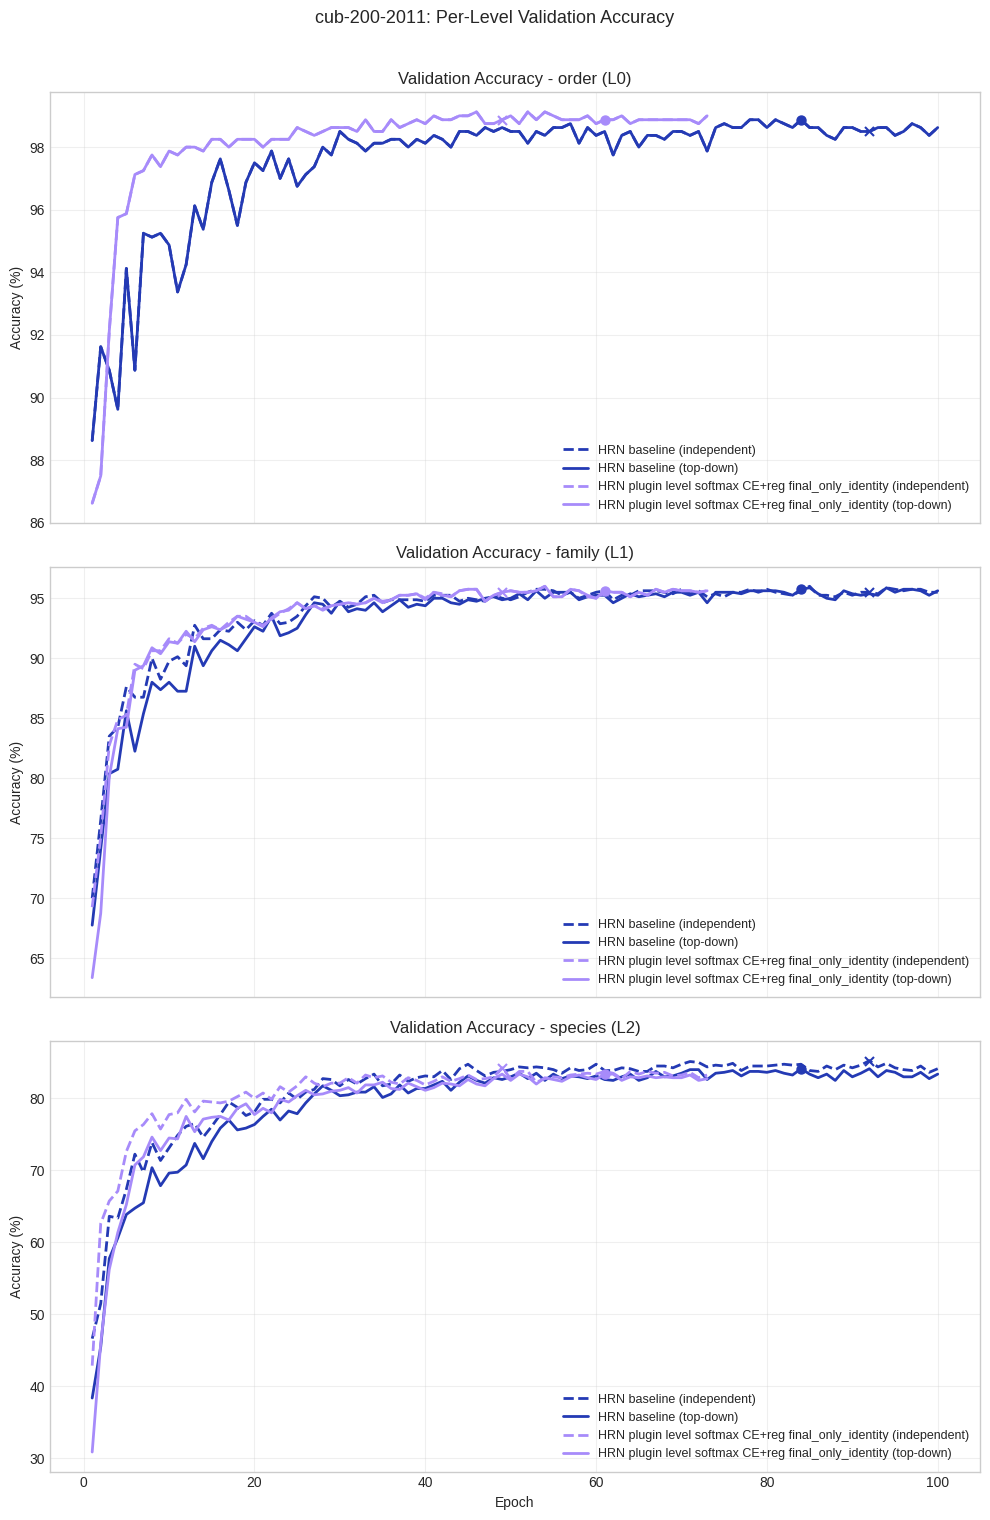

In [89]:
analysis.plot_per_level_validation_accuracy()


## Final Test Comparison Table

For each dataset, the table compares key test metrics for selected HRN runs and reports deltas versus the first run listed for that dataset.

In [90]:
analysis.show_final_test_tables()


### Dataset: `cub-200-2011`
Baseline run: **HRN baseline**

| Metric | HRN baseline | HRN plugin level softmax CE+reg final_only_identity |
|---|---:|---:|
| Best epoch (TD/Ind) | 84/92 | 61/49 |
| FPA independent ↑ | **82.67%** | n/a |
| FPA top-down ↑ | **84.31%** | n/a |
| wAP independent ↑ | **86.95%** | n/a |
| wAP top-down ↑ | **86.62%** | n/a |
| TICE independent ↓ | **4.83%** | n/a |
| TICE top-down ↓ | **0.00%** | n/a |
| AHD independent ↓ | **0.247** | n/a |
| AHD top-down ↓ | **0.224** | n/a |
| Acc independent order (L0) ↑ | **98.60%** | n/a |
| Acc top-down order (L0) ↑ | **98.60%** | n/a |
| Acc independent family (L1) ↑ | **94.54%** | n/a |
| Acc top-down family (L1) ↑ | **94.68%** | n/a |
| Acc independent species (L2) ↑ | **84.75%** | n/a |
| Acc top-down species (L2) ↑ | **84.31%** | n/a |